# Chapter 3.8: Pre-Ranking & Lightweight Scoring

## Learning Objectives

By the end of this notebook, you will be able to:

1. **Explain** why pre-ranking exists: bridging retrieval and full ranking under latency budgets
2. **Describe** COLD (Alibaba): computing-cost-aware lightweight deep model
3. **Implement** knowledge distillation from a full ranking teacher to a pre-ranking student
4. **Design** cascade ranking architectures with multiple stages
5. **Apply** feature selection techniques for minimal-feature pre-ranking
6. **Compare** pre-ranking model architectures by speed-quality trade-off
7. **Train** a pre-ranking model via distillation from a full ranking model

## Prerequisites

- Two-tower retrieval (Chapter 3.1)
- Neural network training basics
- Understanding of ranking metrics

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part3/chapter_3.8_pre_ranking.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://github.com/hideak1/rec_system/raw/main/notebooks/part3/chapter_3.8_pre_ranking.ipynb)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import time
from typing import Dict, List, Tuple
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cpu')
print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.2.2


## 1. Why Pre-Ranking?

A typical recommendation pipeline has a funnel structure:

| Stage | Input Items | Latency Budget | Model Complexity |
|-------|-----------|----------------|------------------|
| **Retrieval** | Millions → ~10K | ~10ms | Two-tower (simple) |
| **Pre-ranking** | ~10K → ~500 | ~10ms | Lightweight MLP |
| **Ranking** | ~500 → ~50 | ~50ms | Complex DNN |
| **Re-ranking** | ~50 → ~20 | ~10ms | Listwise model |

The gap between retrieval (10K candidates) and ranking (500 candidates) is too large for the ranking model to handle. Pre-ranking fills this gap with a model that is:
- **Faster** than the full ranker (fewer features, simpler architecture)
- **Better** than retrieval scores (uses some cross features)

> **💡 Concept:** Pre-ranking is about finding the right accuracy-latency trade-off. It must score ~10K items in ~10ms, which means roughly 1 microsecond per item. Every feature lookup and model operation must be justified.

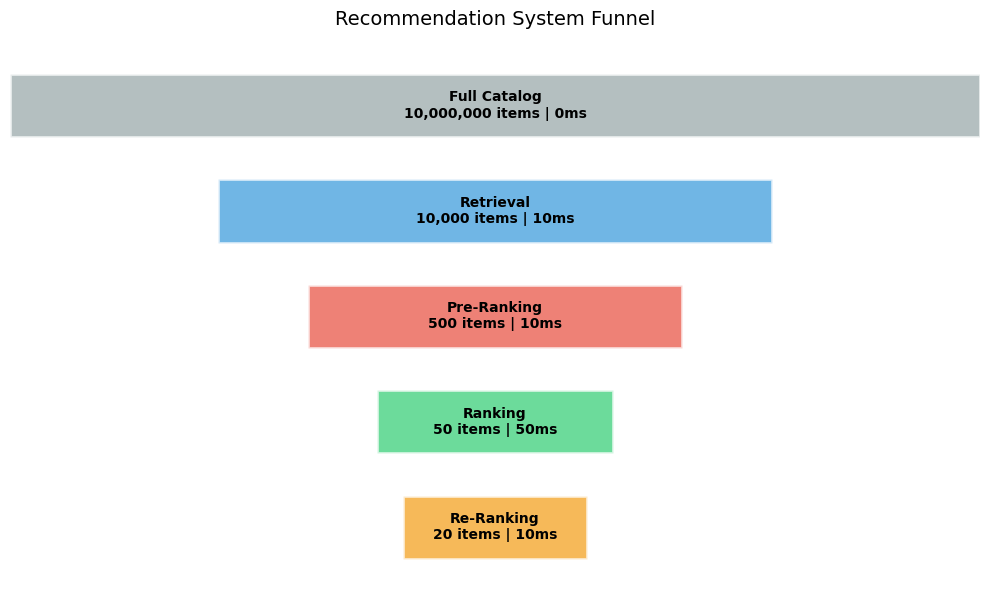

In [2]:
# Visualize the recommendation funnel
fig, ax = plt.subplots(figsize=(10, 6))

stages = ['Full Catalog', 'Retrieval', 'Pre-Ranking', 'Ranking', 'Re-Ranking']
items = [10000000, 10000, 500, 50, 20]
latencies = [0, 10, 10, 50, 10]
colors = ['#95a5a6', '#3498db', '#e74c3c', '#2ecc71', '#f39c12']

# Funnel bars
for i, (stage, count, latency, color) in enumerate(zip(stages, items, latencies, colors)):
    width = np.log10(count + 1) / np.log10(items[0] + 1)
    left = (1 - width) / 2
    ax.barh(len(stages) - i - 1, width, left=left, height=0.6, 
            color=color, alpha=0.7, edgecolor='white', linewidth=2)
    text = f"{stage}\n{count:,} items | {latency}ms"
    ax.text(0.5, len(stages) - i - 1, text, ha='center', va='center', 
            fontsize=10, fontweight='bold')

ax.set_xlim(0, 1)
ax.set_ylim(-0.5, len(stages) - 0.5)
ax.axis('off')
ax.set_title('Recommendation System Funnel', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

## 2. Pre-Ranking Model Design

### Design Principles
1. **Feature economy**: Use only the most informative features
2. **Architectural simplicity**: Shallow MLPs, no complex interactions
3. **Computation awareness**: Every FLOP counts at 10K items/request

### COLD: Computing Power Cost-Aware Online Lightweight Deep Model (Alibaba, 2020)

COLD (Wang et al., 2020) jointly optimizes the model architecture and feature set for a given latency budget:

$$\min_{\theta, \mathcal{F}} \mathcal{L}(\theta, \mathcal{F}) \quad \text{s.t.} \quad \text{Latency}(\theta, \mathcal{F}) \leq T$$

Key ideas:
- Features are selected based on **importance / cost** ratio
- Architecture uses feature interaction-free design when possible
- SE (Squeeze-and-Excitation) blocks for feature importance weighting

In [3]:
# Generate synthetic ranking data
NUM_SAMPLES = 50000
NUM_USER_FEATURES = 20
NUM_ITEM_FEATURES = 30
NUM_CROSS_FEATURES = 15  # Features requiring both user and item info
TOTAL_FEATURES = NUM_USER_FEATURES + NUM_ITEM_FEATURES + NUM_CROSS_FEATURES

# Simulate features with varying importance
np.random.seed(42)
# True feature weights (some features are much more important)
true_weights = np.zeros(TOTAL_FEATURES)
important_features = np.random.choice(TOTAL_FEATURES, 15, replace=False)
true_weights[important_features] = np.random.randn(15) * 2
true_weights += np.random.randn(TOTAL_FEATURES) * 0.1  # Small noise

# Generate features and labels
X = np.random.randn(NUM_SAMPLES, TOTAL_FEATURES).astype(np.float32)
logits = X @ true_weights + np.random.randn(NUM_SAMPLES) * 0.5
y = (logits > 0).astype(np.float32)

X_tensor = torch.tensor(X)
y_tensor = torch.tensor(y)

# Split
train_X, test_X = X_tensor[:40000], X_tensor[40000:]
train_y, test_y = y_tensor[:40000], y_tensor[40000:]

print(f"Features: {TOTAL_FEATURES} (user: {NUM_USER_FEATURES}, item: {NUM_ITEM_FEATURES}, cross: {NUM_CROSS_FEATURES})")
print(f"Important features: {sorted(important_features.tolist())}")
print(f"Train: {len(train_X)}, Test: {len(test_X)}")
print(f"Positive rate: {y.mean():.3f}")

Features: 65 (user: 20, item: 30, cross: 15)
Important features: [0, 5, 9, 12, 13, 16, 30, 33, 34, 41, 45, 53, 60, 61, 64]
Train: 40000, Test: 10000
Positive rate: 0.497


In [4]:
class FullRankingModel(nn.Module):
    """Full ranking model with all features and deep architecture."""
    def __init__(self, input_dim: int, hidden_dims: list = None):
        super().__init__()
        if hidden_dims is None:
            hidden_dims = [256, 128, 64, 32]
        
        layers = []
        in_dim = input_dim
        for h in hidden_dims:
            layers.extend([
                nn.Linear(in_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(0.1)
            ])
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x).squeeze(-1)


class PreRankingModel(nn.Module):
    """Lightweight pre-ranking model with fewer features and simpler architecture."""
    def __init__(self, input_dim: int, hidden_dim: int = 64):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
    
    def forward(self, x):
        return self.network(x).squeeze(-1)


class COLDPreRanker(nn.Module):
    """COLD-style pre-ranker with SE-based feature gating."""
    def __init__(self, input_dim: int, hidden_dim: int = 64, se_ratio: int = 4):
        super().__init__()
        # SE (Squeeze-and-Excitation) block for feature importance
        self.se = nn.Sequential(
            nn.Linear(input_dim, input_dim // se_ratio),
            nn.ReLU(),
            nn.Linear(input_dim // se_ratio, input_dim),
            nn.Sigmoid()
        )
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
    
    def forward(self, x):
        # Feature gating
        gate = self.se(x)
        x_gated = x * gate
        return self.network(x_gated).squeeze(-1)


# Create models
full_ranker = FullRankingModel(TOTAL_FEATURES)
pre_ranker = PreRankingModel(TOTAL_FEATURES, hidden_dim=64)
cold_ranker = COLDPreRanker(TOTAL_FEATURES, hidden_dim=64)

for name, model in [('Full Ranker', full_ranker), ('Pre-Ranker', pre_ranker), ('COLD', cold_ranker)]:
    params = sum(p.numel() for p in model.parameters())
    print(f"{name:15s}: {params:>8,} parameters")

Full Ranker    :   61,121 parameters
Pre-Ranker     :    4,289 parameters
COLD           :    6,450 parameters


In [5]:
# Train full ranking model (teacher)
def train_model(model, train_X, train_y, num_epochs=30, lr=1e-3, batch_size=512):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    dataset = torch.utils.data.TensorDataset(train_X, train_y)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    losses = []
    model.train()
    for epoch in range(num_epochs):
        epoch_loss = 0
        n = 0
        for batch_x, batch_y in loader:
            pred = model(batch_x)
            loss = F.binary_cross_entropy_with_logits(pred, batch_y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n += 1
        losses.append(epoch_loss / n)
    return losses

def evaluate_model(model, test_X, test_y):
    model.eval()
    with torch.no_grad():
        pred = torch.sigmoid(model(test_X))
        predicted = (pred > 0.5).float()
        accuracy = (predicted == test_y).float().mean().item()
        
        # AUC approximation
        pos_mask = test_y == 1
        neg_mask = test_y == 0
        if pos_mask.sum() > 0 and neg_mask.sum() > 0:
            pos_scores = pred[pos_mask]
            neg_scores = pred[neg_mask]
            # Sample pairs for AUC estimation
            n_pairs = min(10000, len(pos_scores) * len(neg_scores))
            pos_sample = pos_scores[torch.randint(len(pos_scores), (n_pairs,))]
            neg_sample = neg_scores[torch.randint(len(neg_scores), (n_pairs,))]
            auc = ((pos_sample > neg_sample).float().mean().item() + 
                   0.5 * (pos_sample == neg_sample).float().mean().item())
        else:
            auc = 0.5
    
    # Measure inference speed
    start = time.time()
    with torch.no_grad():
        for _ in range(10):
            _ = model(test_X)
    latency = (time.time() - start) / 10 / len(test_X) * 1e6  # microseconds per item
    
    return {'accuracy': accuracy, 'auc': auc, 'us_per_item': latency}

print("Training full ranking model (teacher)...")
teacher_losses = train_model(full_ranker, train_X, train_y, num_epochs=30)

teacher_metrics = evaluate_model(full_ranker, test_X, test_y)
print(f"Teacher - Accuracy: {teacher_metrics['accuracy']:.4f}, "
      f"AUC: {teacher_metrics['auc']:.4f}, "
      f"Latency: {teacher_metrics['us_per_item']:.2f} us/item")

Training full ranking model (teacher)...


Teacher - Accuracy: 0.9602, AUC: 0.9963, Latency: 2.26 us/item


## 3. Knowledge Distillation for Pre-Ranking

The full ranking model is the **teacher**; the pre-ranking model is the **student**.

### Distillation Loss

$$\mathcal{L}_{\text{distill}} = \alpha \cdot \text{BCE}(\hat{y}_s, y) + (1 - \alpha) \cdot \text{KL}(\hat{y}_s \| \hat{y}_t)$$

where:
- $\hat{y}_s$ = student prediction
- $\hat{y}_t$ = teacher prediction (soft labels)
- $y$ = ground truth
- $\alpha$ = balancing weight

### Ranking Distillation

Beyond pointwise distillation, we can also distill the ranking order:

$$\mathcal{L}_{\text{rank}} = \sum_{i,j: \hat{y}_{t,i} > \hat{y}_{t,j}} \max(0, \hat{y}_{s,j} - \hat{y}_{s,i} + \delta)$$

> **⚠️ Common Pitfall:** Pure distillation can make the student model "too confident" on easy examples. Mixing hard labels (ground truth) with soft labels (teacher predictions) helps maintain calibration.

In [6]:
def distillation_training(student, teacher, train_X, train_y, 
                           num_epochs=30, alpha=0.5, temperature=3.0, 
                           lr=1e-3, batch_size=512):
    """Train student with distillation from teacher."""
    optimizer = torch.optim.Adam(student.parameters(), lr=lr)
    dataset = torch.utils.data.TensorDataset(train_X, train_y)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    teacher.eval()
    student.train()
    losses = []
    
    for epoch in range(num_epochs):
        epoch_loss = 0
        n = 0
        for batch_x, batch_y in loader:
            # Teacher predictions (soft labels)
            with torch.no_grad():
                teacher_logits = teacher(batch_x)
                teacher_probs = torch.sigmoid(teacher_logits / temperature)
            
            # Student predictions
            student_logits = student(batch_x)
            student_probs = torch.sigmoid(student_logits / temperature)
            
            # Hard label loss
            hard_loss = F.binary_cross_entropy_with_logits(student_logits, batch_y)
            
            # Soft label loss (KL divergence)
            soft_loss = F.binary_cross_entropy(student_probs, teacher_probs)
            
            # Combined loss
            loss = alpha * hard_loss + (1 - alpha) * soft_loss * (temperature ** 2)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            n += 1
        losses.append(epoch_loss / n)
    
    return losses

# Train pre-ranker WITHOUT distillation (baseline)
pre_ranker_no_distill = PreRankingModel(TOTAL_FEATURES, hidden_dim=64)
print("Training pre-ranker without distillation...")
no_distill_losses = train_model(pre_ranker_no_distill, train_X, train_y, num_epochs=30)

# Train pre-ranker WITH distillation
pre_ranker_distill = PreRankingModel(TOTAL_FEATURES, hidden_dim=64)
print("Training pre-ranker with distillation...")
distill_losses = distillation_training(
    pre_ranker_distill, full_ranker, train_X, train_y,
    num_epochs=30, alpha=0.3, temperature=3.0
)

# Train COLD model with distillation
cold_model = COLDPreRanker(TOTAL_FEATURES, hidden_dim=64)
print("Training COLD model with distillation...")
cold_losses = distillation_training(
    cold_model, full_ranker, train_X, train_y,
    num_epochs=30, alpha=0.3, temperature=3.0
)

Training pre-ranker without distillation...


Training pre-ranker with distillation...


Training COLD model with distillation...


Full Ranker (Teacher)          | Acc: 0.9602 | AUC: 0.9969 | Latency: 2.23us | Params: 61,121
Pre-Ranker (No Distill)        | Acc: 0.9739 | AUC: 0.9987 | Latency: 0.26us | Params: 4,289
Pre-Ranker (Distilled)         | Acc: 0.9729 | AUC: 0.9982 | Latency: 0.22us | Params: 4,289
COLD (Distilled)               | Acc: 0.9726 | AUC: 0.9969 | Latency: 0.63us | Params: 6,450


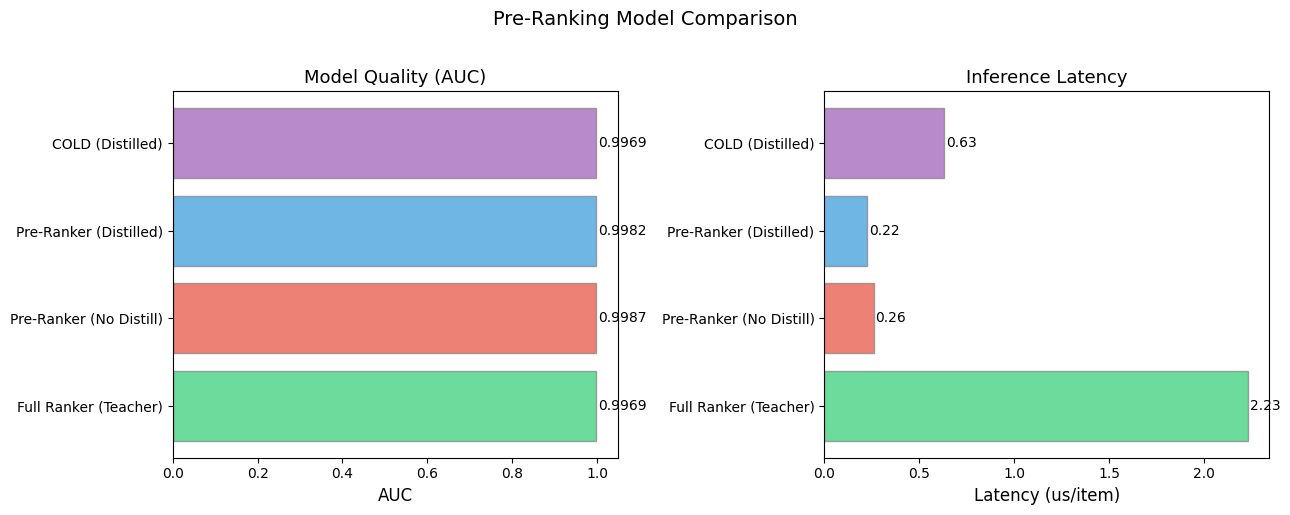

In [7]:
# Evaluate all models
results = {}
models = {
    'Full Ranker (Teacher)': full_ranker,
    'Pre-Ranker (No Distill)': pre_ranker_no_distill,
    'Pre-Ranker (Distilled)': pre_ranker_distill,
    'COLD (Distilled)': cold_model,
}

for name, model in models.items():
    metrics = evaluate_model(model, test_X, test_y)
    params = sum(p.numel() for p in model.parameters())
    results[name] = {**metrics, 'params': params}
    print(f"{name:30s} | Acc: {metrics['accuracy']:.4f} | AUC: {metrics['auc']:.4f} | "
          f"Latency: {metrics['us_per_item']:.2f}us | Params: {params:,}")

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

names = list(results.keys())
aucs = [results[n]['auc'] for n in names]
latencies = [results[n]['us_per_item'] for n in names]
colors_plot = ['#2ecc71', '#e74c3c', '#3498db', '#9b59b6']

axes[0].barh(names, aucs, color=colors_plot, alpha=0.7, edgecolor='gray')
axes[0].set_xlabel('AUC', fontsize=12)
axes[0].set_title('Model Quality (AUC)', fontsize=13)
for i, v in enumerate(aucs):
    axes[0].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=10)

axes[1].barh(names, latencies, color=colors_plot, alpha=0.7, edgecolor='gray')
axes[1].set_xlabel('Latency (us/item)', fontsize=12)
axes[1].set_title('Inference Latency', fontsize=13)
for i, v in enumerate(latencies):
    axes[1].text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=10)

plt.suptitle('Pre-Ranking Model Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. Feature Selection for Pre-Ranking

Not all features are worth the compute cost. Feature selection for pre-ranking:

1. **Importance ranking**: Measure each feature's contribution to prediction quality
2. **Cost analysis**: Estimate the cost of each feature (lookup, computation, network)
3. **Greedy selection**: Add features by importance/cost ratio until latency budget is hit

> **🔑 Pro Tip:** Cross features (requiring both user and item info) are often the most expensive but also most informative. Pre-ranking often uses pre-computed user features + simple item features, avoiding real-time cross features.

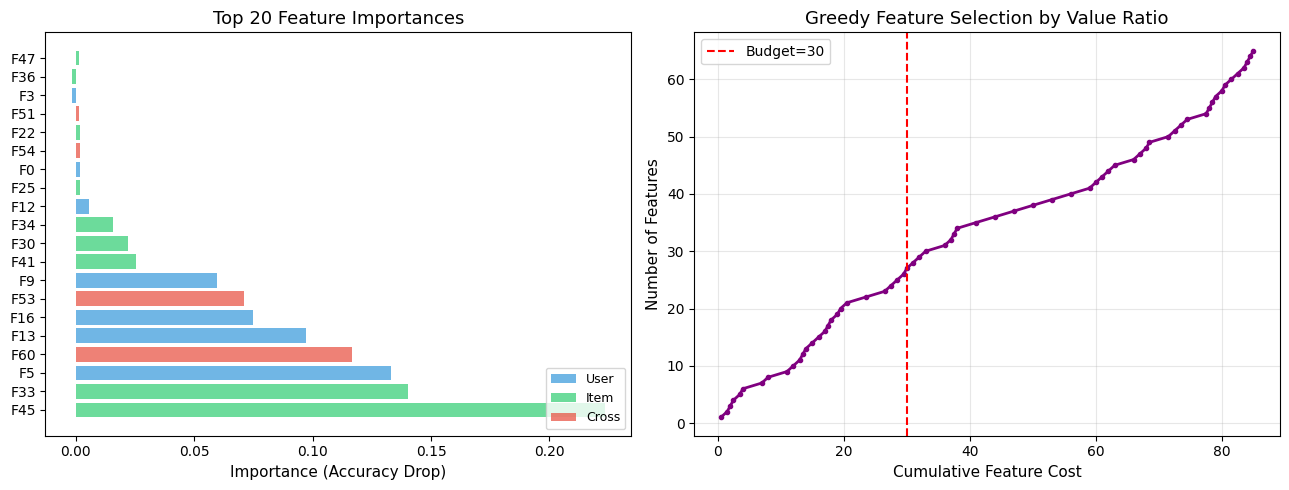

In [8]:
def feature_importance_analysis(model, test_X, test_y, feature_names=None):
    """Compute feature importance via permutation importance."""
    model.eval()
    
    with torch.no_grad():
        base_pred = torch.sigmoid(model(test_X))
        base_acc = ((base_pred > 0.5).float() == test_y).float().mean().item()
    
    importances = []
    for feat_idx in range(test_X.size(1)):
        # Permute feature
        X_permuted = test_X.clone()
        perm = torch.randperm(test_X.size(0))
        X_permuted[:, feat_idx] = test_X[perm, feat_idx]
        
        with torch.no_grad():
            perm_pred = torch.sigmoid(model(X_permuted))
            perm_acc = ((perm_pred > 0.5).float() == test_y).float().mean().item()
        
        importances.append(base_acc - perm_acc)  # Drop in accuracy
    
    return np.array(importances)

importances = feature_importance_analysis(full_ranker, test_X, test_y)

# Assign feature costs (user < item < cross)
feature_costs = np.ones(TOTAL_FEATURES)
feature_costs[:NUM_USER_FEATURES] = 0.5  # User features are cheap (pre-computed)
feature_costs[NUM_USER_FEATURES:NUM_USER_FEATURES+NUM_ITEM_FEATURES] = 1.0
feature_costs[-NUM_CROSS_FEATURES:] = 3.0  # Cross features are expensive

# Importance / cost ratio
value_ratio = importances / feature_costs

# Select top features by value ratio
sorted_features = np.argsort(-value_ratio)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Feature importance
top_n = 20
top_idx = np.argsort(-np.abs(importances))[:top_n]
colors_feat = []
for idx in top_idx:
    if idx < NUM_USER_FEATURES:
        colors_feat.append('#3498db')
    elif idx < NUM_USER_FEATURES + NUM_ITEM_FEATURES:
        colors_feat.append('#2ecc71')
    else:
        colors_feat.append('#e74c3c')

axes[0].barh(range(top_n), importances[top_idx], color=colors_feat, alpha=0.7)
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels([f'F{i}' for i in top_idx])
axes[0].set_xlabel('Importance (Accuracy Drop)', fontsize=11)
axes[0].set_title('Top 20 Feature Importances', fontsize=13)
# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498db', alpha=0.7, label='User'),
    Patch(facecolor='#2ecc71', alpha=0.7, label='Item'),
    Patch(facecolor='#e74c3c', alpha=0.7, label='Cross')
]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=9)

# Greedy feature selection curve
selected_features_cumulative = []
cum_cost = 0
cum_features = []
for feat in sorted_features:
    cum_cost += feature_costs[feat]
    cum_features.append(feat)
    selected_features_cumulative.append((cum_cost, len(cum_features)))

costs_cum, n_feats_cum = zip(*selected_features_cumulative)
axes[1].plot(costs_cum, n_feats_cum, 'o-', color='purple', linewidth=2, markersize=3)
axes[1].set_xlabel('Cumulative Feature Cost', fontsize=11)
axes[1].set_ylabel('Number of Features', fontsize=11)
axes[1].set_title('Greedy Feature Selection by Value Ratio', fontsize=13)
axes[1].axvline(x=30, color='red', linestyle='--', label='Budget=30')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Cascade Ranking Architecture

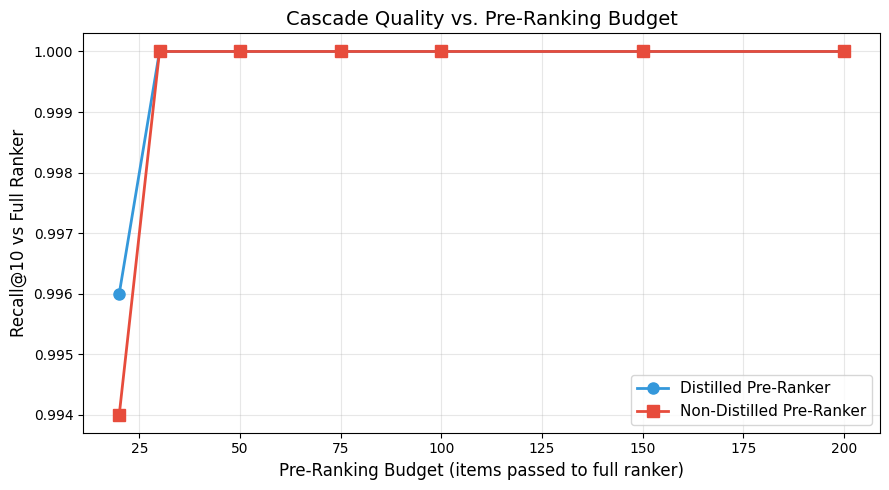

In [9]:
def cascade_ranking_simulation(full_ranker, pre_ranker, test_X, test_y,
                                retrieval_k=200, prerank_k=50, rank_k=10):
    """Simulate a cascade ranking pipeline."""
    full_ranker.eval()
    pre_ranker.eval()
    
    # Simulate: for each "query", we have retrieval_k candidates
    n_queries = len(test_X) // retrieval_k
    
    cascade_recalls = []
    direct_recalls = []
    
    for q in range(n_queries):
        start = q * retrieval_k
        end = start + retrieval_k
        candidates_X = test_X[start:end]
        candidates_y = test_y[start:end]
        
        # Ground truth: top-K by full ranker
        with torch.no_grad():
            full_scores = full_ranker(candidates_X)
            full_top_k = full_scores.topk(rank_k).indices.numpy()
        
        # Cascade: pre-rank first, then full rank on subset
        with torch.no_grad():
            pre_scores = pre_ranker(candidates_X)
            pre_top_k = pre_scores.topk(prerank_k).indices
        
        # Full rank on pre-ranked subset
        preranked_X = candidates_X[pre_top_k]
        with torch.no_grad():
            reranked_scores = full_ranker(preranked_X)
            reranked_top_k = reranked_scores.topk(rank_k).indices.numpy()
        
        # Map back to original indices
        cascade_top_k = pre_top_k[reranked_top_k].numpy()
        
        # Recall: how many of full ranker's top-K are in cascade's top-K?
        recall = len(set(full_top_k.tolist()) & set(cascade_top_k.tolist())) / rank_k
        cascade_recalls.append(recall)
    
    return np.mean(cascade_recalls)

# Test cascade with different pre-ranking budgets
prerank_budgets = [20, 30, 50, 75, 100, 150, 200]
recalls_distill = []
recalls_no_distill = []

for budget in prerank_budgets:
    r_d = cascade_ranking_simulation(
        full_ranker, pre_ranker_distill, test_X, test_y,
        retrieval_k=200, prerank_k=budget, rank_k=10
    )
    r_nd = cascade_ranking_simulation(
        full_ranker, pre_ranker_no_distill, test_X, test_y,
        retrieval_k=200, prerank_k=budget, rank_k=10
    )
    recalls_distill.append(r_d)
    recalls_no_distill.append(r_nd)

plt.figure(figsize=(9, 5))
plt.plot(prerank_budgets, recalls_distill, 'o-', color='#3498db', 
         linewidth=2, markersize=8, label='Distilled Pre-Ranker')
plt.plot(prerank_budgets, recalls_no_distill, 's-', color='#e74c3c', 
         linewidth=2, markersize=8, label='Non-Distilled Pre-Ranker')
plt.xlabel('Pre-Ranking Budget (items passed to full ranker)', fontsize=12)
plt.ylabel('Recall@10 vs Full Ranker', fontsize=12)
plt.title('Cascade Quality vs. Pre-Ranking Budget', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Exercises

### 🏋️ Exercise 1: Implement Ranking-Aware Distillation

Instead of just matching the teacher's scores, preserve the ranking order.

In [10]:
def ranking_distillation_loss(student_scores, teacher_scores, margin=0.1):
    """
    Pairwise ranking distillation: preserve the teacher's ordering.
    
    For all pairs where teacher_i > teacher_j,
    ensure student_i > student_j - margin.
    
    Args:
        student_scores: (B,) student predictions
        teacher_scores: (B,) teacher predictions
        margin: ranking margin
    
    Returns:
        Pairwise ranking loss
    """
    # TODO: Sample pairs where teacher has clear preference
    # TODO: Compute pairwise hinge loss
    # TODO: Return average loss
    pass

### 🏋️ Exercise 2: Feature-Selected Pre-Ranker

Train a pre-ranker using only the top-K features selected by importance/cost ratio.

In [11]:
def train_feature_selected_preranker(full_ranker, train_X, train_y, test_X, test_y,
                                      importances, feature_costs,
                                      cost_budget=30):
    """
    Select features within cost budget and train a pre-ranker.
    
    Steps:
    1. Rank features by importance/cost ratio
    2. Greedily select until cost budget is reached
    3. Train pre-ranker on selected features with distillation
    4. Evaluate and compare with full-feature pre-ranker
    
    Returns:
        model, selected_features, metrics
    """
    # TODO: Greedy feature selection
    # TODO: Train on selected features
    # TODO: Evaluate
    pass

### 🏋️ Exercise 3: Adaptive Cascade with Dynamic Budget Allocation

Different queries may need different pre-ranking budgets. Implement a routing mechanism that allocates compute based on query difficulty.

In [12]:
class AdaptiveCascade(nn.Module):
    """Cascade ranking with adaptive pre-ranking budget."""
    def __init__(self, pre_ranker, full_ranker, budget_predictor_dim=32):
        super().__init__()
        # TODO: Budget predictor: given query features, predict
        #       how many items the pre-ranker should pass through
        # TODO: Options: [20, 50, 100, 200]
        # TODO: Train budget predictor to maximize quality
        #       while meeting average latency constraint
        pass
    
    def forward(self, query_features, candidate_features):
        # TODO: Predict budget
        # TODO: Pre-rank with predicted budget
        # TODO: Full rank on subset
        pass

## Summary

| Aspect | Key Takeaway |
|--------|-------------|
| **Why pre-ranking** | Bridges retrieval (~10K items) and ranking (~500 items) under strict latency |
| **COLD** | SE-based feature gating + latency-aware architecture search |
| **Distillation** | Train lightweight student from complex teacher; mix hard and soft labels |
| **Feature selection** | Rank by importance/cost ratio; avoid expensive cross features |
| **Cascade design** | Distilled pre-ranker recovers 90%+ of full ranker quality at 50-100 items |

**Next up**: Chapter 3.9 covers Multi-Source Retrieval Fusion — combining candidates from multiple retrieval channels.